Problem 1


1-Write a Python program to find the maximum likelihood values 𝜇̂ and 𝜎̂2. Apply your program individually to each of the three features 𝑥𝑖 of category 𝜔1 in the table above.

In [1]:
import numpy as np
import re
from pathlib import Path

# Load ω1 block from Assignment3_dataset.txt
text = Path("/content/drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt").read_text()
block = re.search(r"W1\s*(.*?)\s*W2", text, flags=re.S).group(1)
rows = [list(map(float, re.findall(r"[-+]?\d*\.\d+|\d+", line)))[:3]
        for line in block.splitlines() if line.strip()]
W1 = np.array(rows)

def mle_mean_var(x):
    mu = x.mean()
    var = ((x - mu)**2).mean()     # divide by N → MLE variance
    return mu, var

for j, name in enumerate(["x1","x2","x3"]):
    mu, var = mle_mean_var(W1[:, j])
    print(f"{name}: μ̂={mu:.6f}, σ̂²={var:.6f}")


x1: μ̂=-0.070900, σ̂²=0.906177
x2: μ̂=-0.604700, σ̂²=4.200715
x3: μ̂=-0.911000, σ̂²=4.541949


2. Modify your program to apply to two-dimensional Gaussian data 𝑝(𝑥)~𝑁(𝜇,Σ). Apply your data to each of the three possible pairings of two features for 𝜔1.

In [2]:
import numpy as np
import re
from pathlib import Path

# Load ω1 block from Assignment3_dataset.txt
text = Path("/content/drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt").read_text()
block = re.search(r"W1\s*(.*?)\s*W2", text, flags=re.S).group(1)
rows = [list(map(float, re.findall(r"[-+]?\d*\.\d+|\d+", line)))[:3]
        for line in block.splitlines() if line.strip()]
W1 = np.array(rows)

# ---------- Q1 : univariate MLE----------
def mle_mean_var(x):
    mu = x.mean()
    var = ((x - mu)**2).mean()     # MLE (divide by N)
    return mu, var

for j, name in enumerate(["x1","x2","x3"]):
    mu, var = mle_mean_var(W1[:, j])
    print(f"{name}: μ̂={mu:.6f}, σ̂²={var:.6f}")

# ---------- Q2: 2-D Gaussian MLE for each feature pair ----------
def mle_mean_cov(X2d: np.ndarray):
    """Return (μ̂, Σ̂) for 2-D data matrix X2d of shape (N,2), using MLE (1/N)."""
    mu = X2d.mean(axis=0)
    Xc = X2d - mu
    Sigma = (Xc.T @ Xc) / X2d.shape[0]   # MLE covariance
    return mu, Sigma

np.set_printoptions(precision=8, suppress=True)

pairs = [("x1,x2", (0, 1)),
         ("x1,x3", (0, 2)),
         ("x2,x3", (1, 2))]

print("\n=== Q2: 2-D MLE results for ω1 ===")
for name, (i, j) in pairs:
    mu_hat, Sigma_hat = mle_mean_cov(W1[:, [i, j]])
    print(f"Pair ({name})")
    print(f"  μ̂ = {mu_hat}")
    print(f"  Σ̂ =\n{Sigma_hat}\n")


x1: μ̂=-0.070900, σ̂²=0.906177
x2: μ̂=-0.604700, σ̂²=4.200715
x3: μ̂=-0.911000, σ̂²=4.541949

=== Q2: 2-D MLE results for ω1 ===
Pair (x1,x2)
  μ̂ = [-0.0709 -0.6047]
  Σ̂ =
[[0.90617729 0.56778177]
 [0.56778177 4.20071481]]

Pair (x1,x3)
  μ̂ = [-0.0709 -0.911 ]
  Σ̂ =
[[0.90617729 0.3940801 ]
 [0.3940801  4.541949  ]]

Pair (x2,x3)
  μ̂ = [-0.6047 -0.911 ]
  Σ̂ =
[[4.20071481 0.7337023 ]
 [0.7337023  4.541949  ]]



3. Modify your program to apply to three-dimensional Gaussian data. Apply your data to the full three-dimensional data for 𝜔1.

In [3]:
import numpy as np
import re
from pathlib import Path

# Load ω1 block from Assignment3_dataset.txt
text = Path("/content/drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt").read_text()
block = re.search(r"W1\s*(.*?)\s*W2", text, flags=re.S).group(1)
rows = [list(map(float, re.findall(r"[-+]?\d*\.\d+|\d+", line)))[:3]
        for line in block.splitlines() if line.strip()]
W1 = np.array(rows)                    # shape: (10, 3)

# --- Q1 : univariate MLE for reference ---
def mle_mean_var(x):
    mu = x.mean()
    var = ((x - mu)**2).mean()         # MLE uses 1/N
    return mu, var

for j, name in enumerate(["x1","x2","x3"]):
    mu, var = mle_mean_var(W1[:, j])
    print(f"{name}: μ̂={mu:.6f}, σ̂²={var:.6f}")

# --- Q2 : 2-D MLE for each pair  ---
def mle_mean_cov_2d(X2):
    mu = X2.mean(axis=0)
    Xc = X2 - mu
    Sigma = (Xc.T @ Xc) / X2.shape[0]  # MLE covariance (1/N)
    return mu, Sigma

# --- Q3: 3-D MLE for full ω1 ---
def mle_mean_cov_3d(X3):
    mu = X3.mean(axis=0)               # (3,)
    Xc = X3 - mu                       # (N,3)
    Sigma = (Xc.T @ Xc) / X3.shape[0]  # (3,3) MLE covariance
    return mu, Sigma

mu_3d, Sigma_3d = mle_mean_cov_3d(W1)
np.set_printoptions(precision=8, suppress=True)
print("\n=== Q3: 3-D MLE for ω1 ===")
print("μ̂ =", mu_3d)
print("Σ̂ =\n", Sigma_3d)


x1: μ̂=-0.070900, σ̂²=0.906177
x2: μ̂=-0.604700, σ̂²=4.200715
x3: μ̂=-0.911000, σ̂²=4.541949

=== Q3: 3-D MLE for ω1 ===
μ̂ = [-0.0709 -0.6047 -0.911 ]
Σ̂ =
 [[0.90617729 0.56778177 0.3940801 ]
 [0.56778177 4.20071481 0.7337023 ]
 [0.3940801  0.7337023  4.541949  ]]


4. Assume your three-dimensional model is separable, so that Σ=𝑑𝑖𝑎𝑔(𝜎12,𝜎22,𝜎32). Write a program to estimate the mean and the diagonal components of 𝛴. Apply your program to the data in 𝜔2.

In [4]:
# ===============================
# Q4 - Task A: Estimate mean vector μ̂ for ω₂
# ===============================

import numpy as np, re
from pathlib import Path

# Load ω₂ block from dataset
text = Path("/content/drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt").read_text()
block_w2 = re.search(r"W2\s*(.*?)\s*W3", text, flags=re.S).group(1)

# Convert block to numeric array (x1, x2, x3)
rows = [list(map(float, re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", line)))[:3]
        for line in block_w2.splitlines() if line.strip()]
W2 = np.asarray(rows, dtype=float)

# Compute mean vector μ̂
mu_hat_w2 = W2.mean(axis=0)

print("=== Q4 - Task A: Mean vector for ω₂ ===")
print("μ̂ =", mu_hat_w2)


=== Q4 - Task A: Mean vector for ω₂ ===
μ̂ = [-0.1126   0.4299   0.00372]


In [5]:
# ===============================
# Q4 - Task B: Estimate diagonal covariance Σ̂ = diag(σ₁², σ₂², σ₃²)
# ===============================

# Use same W2 and mu_hat_w2 from Task A

# Compute per-feature MLE variances (divide by N)
diag_vars_w2 = ((W2 - mu_hat_w2)**2).mean(axis=0)
Sigma_diag_w2 = np.diag(diag_vars_w2)

print("\n=== Q4 - Task B: Diagonal covariance for ω₂ ===")
print("σ̂² (per feature) =", diag_vars_w2)
print("Σ̂ =\n", Sigma_diag_w2)



=== Q4 - Task B: Diagonal covariance for ω₂ ===
σ̂² (per feature) = [0.05392584 0.04597009 0.00726551]
Σ̂ =
 [[0.05392584 0.         0.        ]
 [0.         0.04597009 0.        ]
 [0.         0.         0.00726551]]


Problem 3:


1.
Write an EM program in Python to estimate the mean and covariance of the distribution. Start your estimate with 𝜇0=0 and Σ0=𝐼, the three-dimensional identity matrix. Display the obtained result in form of clusters.
(Hint: for the missing 𝑥3, you can simply attribute the value zero or 𝑥1+𝑥22 . In addition, I provided you the implementation of GMM)

Estimated mean (mu):
 [-0.0709     -0.6047      0.77281547]

Estimated covariance (Sigma):
 [[0.90617729 0.56778177 0.88143697]
 [0.56778177 4.20071481 0.46210708]
 [0.88143697 0.46210708 1.78281089]]

Imputed x3 for even-numbered points (rows 2,4,6,8,10):
 row 2: x3 = 0.708554
 row 4: x3 = 1.197072
 row 6: x3 = 0.779133
 row 8: x3 = 1.102272
 row 10: x3 = 1.711124


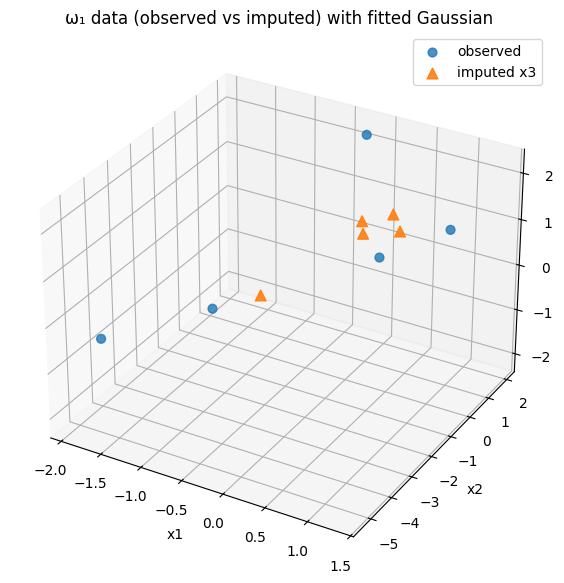

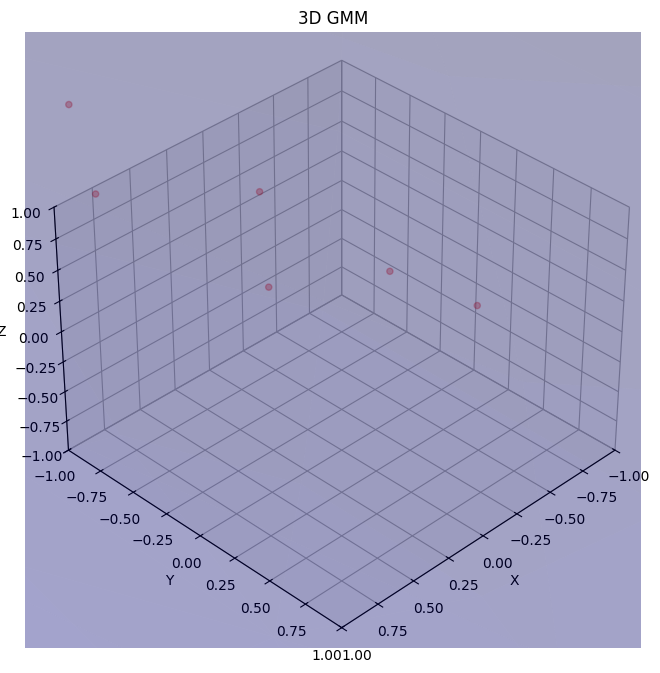

In [10]:


import re
import numpy as np
import matplotlib.pyplot as plt
import visualization  # module with visualize_3d_gmm :contentReference[oaicite:3]{index=3}

# --------------------------------------------------------------------------
# 1) Load W1 from the assignment dataset and mask x3 for even-numbered points
# --------------------------------------------------------------------------
DATA_PATH = "/content/drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt"  # <-- change if needed

with open(DATA_PATH, "r") as f:
    raw = f.read()

# Parse the W1 block (10 rows × 3 cols) from the file :contentReference[oaicite:4]{index=4}
w1_block = re.search(r"W1\s*(.*?)\s*W2", raw, flags=re.S|re.M).group(1).strip()
rows = [re.split(r"\s+", line.strip()) for line in w1_block.splitlines() if line.strip()]
W1 = np.array(rows, dtype=float)    # shape (10,3)
N, D = W1.shape
assert (N, D) == (10, 3), "Expected W1 to be 10x3."

# Create X with missing x3 for even-numbered points (indices 1,3,5,7,9 -> rows 2,4,6,8,10)
X = W1.copy()
even_idx = np.array([1, 3, 5, 7, 9])
X[even_idx, 2] = np.nan

# -----------------------------------------------------------------------------
# 2) EM for a single multivariate Gaussian with missing entries (only x3 missing)
# -----------------------------------------------------------------------------
def em_single_gaussian_missing(
    X,
    mu0=None,
    Sigma0=None,
    max_iter=500,
    tol=1e-8
):
    """
    X: (N,D) with NaNs indicating missing values.
    Returns: mu (D,), Sigma (D,D), X_imputed (N,D), history
    """
    N, D = X.shape
    if mu0 is None:
        mu = np.zeros(D)
    else:
        mu = mu0.astype(float)

    if Sigma0 is None:
        Sigma = np.eye(D)
    else:
        Sigma = Sigma0.astype(float)

    history = []
    for it in range(max_iter):
        # E-step: compute E[x_i] and E[x_i x_i^T] for each i
        Ex = np.zeros((N, D))
        ExxT = np.zeros((N, D, D))

        for i in range(N):
            obs = ~np.isnan(X[i])      # observed mask
            mis = ~obs                 # missing mask
            xo = X[i, obs]

            mu_o = mu[obs]
            mu_m = mu[mis]

            Sigma_oo = Sigma[np.ix_(obs, obs)]
            Sigma_om = Sigma[np.ix_(obs, mis)]
            Sigma_mo = Sigma[np.ix_(mis, obs)]
            Sigma_mm = Sigma[np.ix_(mis, mis)]

            if mis.any():
                # Conditional of x_m | x_o under current (mu, Sigma)
                Sigma_oo_inv = np.linalg.pinv(Sigma_oo)
                mu_cond = mu_m + Sigma_mo @ Sigma_oo_inv @ (xo - mu_o)
                Sigma_cond = Sigma_mm - Sigma_mo @ Sigma_oo_inv @ Sigma_om

                x_full = np.zeros(D)
                x_full[obs] = xo
                x_full[mis] = mu_cond
                Ex[i] = x_full

                Exx = np.zeros((D, D))
                Exx[np.ix_(obs, obs)] = np.outer(xo, xo)
                Exx[np.ix_(obs, mis)] = np.outer(xo, mu_cond)
                Exx[np.ix_(mis, obs)] = np.outer(mu_cond, xo)
                Exx[np.ix_(mis, mis)] = Sigma_cond + np.outer(mu_cond, mu_cond)
                ExxT[i] = Exx
            else:
                Ex[i] = X[i]
                ExxT[i] = np.outer(X[i], X[i])

        # M-step:
        mu_new = Ex.mean(axis=0)
        S2 = ExxT.mean(axis=0)                 # (1/N) * sum E[x x^T]
        Sigma_new = S2 - np.outer(mu_new, mu_new)
        Sigma_new = 0.5 * (Sigma_new + Sigma_new.T)  # symmetrize

        # Convergence
        delta = np.linalg.norm(mu_new - mu) + np.linalg.norm(Sigma_new - Sigma, ord='fro')
        history.append(delta)
        mu, Sigma = mu_new, Sigma_new
        if delta < tol:
            break

    # Impute missing entries with final conditional expectations
    X_imp = X.copy()
    for i in range(N):
        obs = ~np.isnan(X[i])
        mis = ~obs
        if mis.any():
            xo = X[i, obs]
            mu_o = mu[obs]
            mu_m = mu[mis]
            Sigma_oo = Sigma[np.ix_(obs, obs)]
            Sigma_mo = Sigma[np.ix_(mis, obs)]
            x_m_cond = mu_m + Sigma_mo @ np.linalg.pinv(Sigma_oo) @ (xo - mu_o)
            X_imp[i, mis] = x_m_cond
    return mu, Sigma, X_imp, history

# -----------------------------------------------------------------------------
# 3) Pick initial "fill" for the *data view* only (for plotting/inspect); EM still uses μ0=0, Σ0=I
#    (both options are acceptable per the hint)
# -----------------------------------------------------------------------------
def initial_fill(X, mode="zero"):
    X0 = X.copy()
    mis_mask = np.isnan(X0[:, 2])
    if mode == "zero":
        X0[mis_mask, 2] = 0.0
    elif mode == "half_sum":
        X0[mis_mask, 2] = (X0[mis_mask, 0] + X0[mis_mask, 1]) / 2.0
    else:
        raise ValueError("mode must be 'zero' or 'half_sum'")
    return X0


X0_zero = initial_fill(X, mode="zero")
X0_half = initial_fill(X, mode="half_sum")

# -----------------------------------------------------------------------------
# 4) Run EM from μ0=0 and Σ0=I
# -----------------------------------------------------------------------------
mu0 = np.zeros(3)
Sigma0 = np.eye(3)

mu_hat, Sigma_hat, X_imputed, hist = em_single_gaussian_missing(X, mu0=mu0, Sigma0=Sigma0, max_iter=1000, tol=1e-10)

print("Estimated mean (mu):\n", mu_hat)
print("\nEstimated covariance (Sigma):\n", Sigma_hat)
print("\nImputed x3 for even-numbered points (rows 2,4,6,8,10):")
for r in [1,3,5,7,9]:
    print(f" row {r+1}: x3 = {X_imputed[r,2]:.6f}")

# -----------------------------------------------------------------------------
# 5) Display result "in form of clusters"
#    We'll scatter the 3D points (observed vs. missing-imputed) and overlay the fitted Gaussian
# -----------------------------------------------------------------------------
def plot_points_and_gaussian(X_observed, X_imputed, mu, Sigma):
    # Points: use imputed set for complete 3D scatter; mark those that were missing x3
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection="3d")
    # Indices with originally-missing x3
    mis_mask = np.isnan(X[:,2])
    # Plot originally-observed points
    ax.scatter(X_imputed[~mis_mask,0], X_imputed[~mis_mask,1], X_imputed[~mis_mask,2], alpha=0.8, label="observed", s=40)
    # Plot imputed points
    ax.scatter(X_imputed[mis_mask,0], X_imputed[mis_mask,1], X_imputed[mis_mask,2], alpha=0.9, marker="^", label="imputed x3", s=60)

    ax.set_title("ω₁ data (observed vs imputed) with fitted Gaussian")
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
    ax.legend(loc="best")
    plt.show()

    # Draw one Gaussian ellipsoid using your helper (assumes diagonal radii)
    # visualization.visualize_3d_gmm expects stdev as diagonal scales; we'll pass sqrt(diag(Sigma))
    stdev_diag = np.sqrt(np.clip(np.diag(Sigma), 1e-12, None))
    visualization.visualize_3d_gmm(
        points=X_imputed,
        w=np.array([1.0]),                 # single component
        mu=mu.reshape(3,1),
        stdev=stdev_diag.reshape(3,1),
        export=False
    )

plot_points_and_gaussian(X, X_imputed, mu_hat, Sigma_hat)


2.
Compare your final estimate with that for the case when there is no missing data. Display the obtained result in form of clusters.

=== EM (with missing x3) ===
mu_em = [-0.0709   -0.6047    0.772815]
Sigma_em =
 [[0.906177 0.567782 0.881437]
 [0.567782 4.200715 0.462107]
 [0.881437 0.462107 1.782811]]

=== Full-data MLE (no missing) ===
mu_full = [-0.0709 -0.6047 -0.911 ]
Sigma_full =
 [[0.906177 0.567782 0.39408 ]
 [0.567782 4.200715 0.733702]
 [0.39408  0.733702 4.541949]]

||mu_em - mu_full||_2 = 1.6838154672374506
||Sigma_em - Sigma_full||_F = 2.8697394391625464


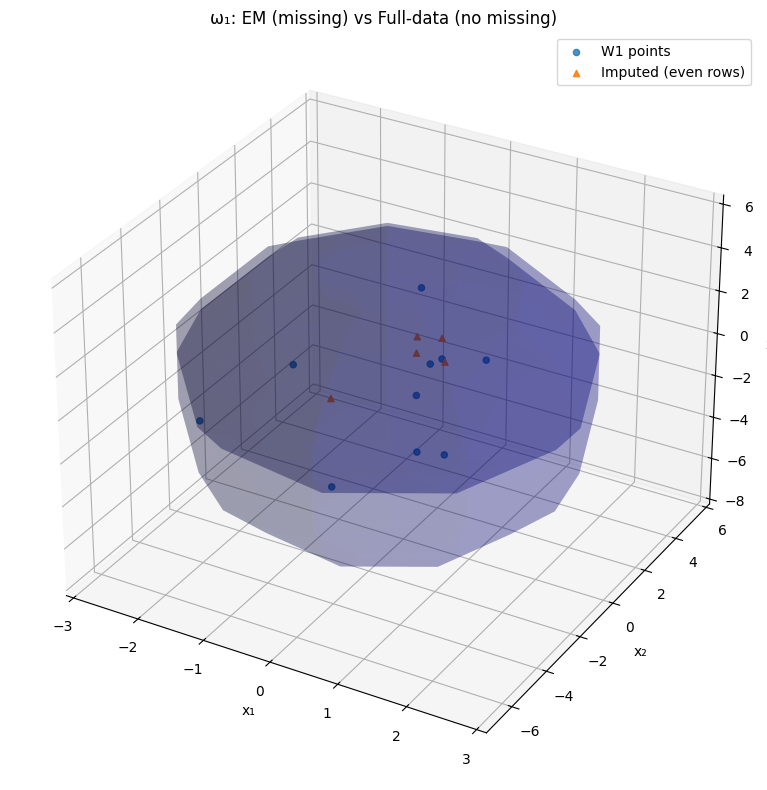


Saved figure: W1_Q2_comparison_fixed.png


In [12]:
# === Task 2 (fixed version): Compare EM estimate vs Full-data MLE ===
# Start with μ0 = 0 and Σ0 = I,.


import re, sys, numpy as np, matplotlib.pyplot as plt, os

DATA_PATH = "/content/drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt"  # <-- adjust if needed

try:
    import visualization
except ImportError:
    sys.path.append(".")
    import visualization

# ---------- Load W1 ----------
with open(DATA_PATH, "r") as f:
    raw = f.read()

w1_block = re.search(r"W1\s*(.*?)\s*W2", raw, flags=re.S|re.M).group(1).strip()
rows = [re.split(r"\s+", line.strip()) for line in w1_block.splitlines() if line.strip()]
W1 = np.array(rows, dtype=float)
assert W1.shape == (10, 3)

# Mask x3 for even-numbered rows (2,4,6,8,10)
X = W1.copy()
even_idx = np.array([1, 3, 5, 7, 9])
X[even_idx, 2] = np.nan

# ---------- EM implementation ----------
def em_single_gaussian_missing(X, mu0=None, Sigma0=None, max_iter=1000, tol=1e-10):
    N, D = X.shape
    mu = np.zeros(D) if mu0 is None else mu0.astype(float)
    Sigma = np.eye(D) if Sigma0 is None else Sigma0.astype(float)
    for _ in range(max_iter):
        Ex = np.zeros((N, D))
        ExxT = np.zeros((N, D, D))
        for i in range(N):
            obs = ~np.isnan(X[i])
            mis = ~obs
            xo = X[i, obs]
            mu_o = mu[obs]; mu_m = mu[mis]
            S_oo = Sigma[np.ix_(obs, obs)]
            S_om = Sigma[np.ix_(obs, mis)]
            S_mo = Sigma[np.ix_(mis, obs)]
            S_mm = Sigma[np.ix_(mis, mis)]
            if mis.any():
                S_oo_inv = np.linalg.pinv(S_oo)
                mu_cond = mu_m + S_mo @ S_oo_inv @ (xo - mu_o)
                S_cond = S_mm - S_mo @ S_oo_inv @ S_om
                x_full = np.zeros(D)
                x_full[obs] = xo
                x_full[mis] = mu_cond
                Ex[i] = x_full
                Exx = np.zeros((D, D))
                Exx[np.ix_(obs, obs)] = np.outer(xo, xo)
                Exx[np.ix_(obs, mis)] = np.outer(xo, mu_cond)
                Exx[np.ix_(mis, obs)] = np.outer(mu_cond, xo)
                Exx[np.ix_(mis, mis)] = S_cond + np.outer(mu_cond, mu_cond)
                ExxT[i] = Exx
            else:
                Ex[i] = X[i]
                ExxT[i] = np.outer(X[i], X[i])
        mu_new = Ex.mean(axis=0)
        S2 = ExxT.mean(axis=0)
        Sigma_new = S2 - np.outer(mu_new, mu_new)
        Sigma_new = 0.5 * (Sigma_new + Sigma_new.T)
        delta = np.linalg.norm(mu_new - mu) + np.linalg.norm(Sigma_new - Sigma, ord='fro')
        mu, Sigma = mu_new, Sigma_new
        if delta < tol:
            break

    # Impute missing
    X_imp = X.copy()
    for i in range(N):
        obs = ~np.isnan(X[i]); mis = ~obs
        if mis.any():
            xo = X[i, obs]
            mu_o = mu[obs]; mu_m = mu[mis]
            S_oo = Sigma[np.ix_(obs, obs)]
            S_mo = Sigma[np.ix_(mis, obs)]
            X_imp[i, mis] = mu_m + S_mo @ np.linalg.pinv(S_oo) @ (xo - mu_o)
    return mu, Sigma, X_imp

# ---------- Case 1: EM (missing) ----------
mu_em, Sigma_em, X_imp = em_single_gaussian_missing(X, mu0=np.zeros(3), Sigma0=np.eye(3))

# ---------- Case 2: Full-data MLE ----------
mu_full = W1.mean(axis=0)
S2_full = (W1[:, :, None] @ W1[:, None, :]).mean(axis=0)
Sigma_full = S2_full - np.outer(mu_full, mu_full)
Sigma_full = 0.5 * (Sigma_full + Sigma_full.T)

# ---------- Print results ----------
np.set_printoptions(precision=6, suppress=False)
print("=== EM (with missing x3) ===")
print("mu_em =", mu_em)
print("Sigma_em =\n", Sigma_em)
print("\n=== Full-data MLE (no missing) ===")
print("mu_full =", mu_full)
print("Sigma_full =\n", Sigma_full)

mu_err = np.linalg.norm(mu_em - mu_full)
Sigma_err = np.linalg.norm(Sigma_em - Sigma_full, ord='fro')
print("\n||mu_em - mu_full||_2 =", mu_err)
print("||Sigma_em - Sigma_full||_F =", Sigma_err)

# ---------- Visualization ----------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(W1[:, 0], W1[:, 1], W1[:, 2], label="W1 points", alpha=0.8)
mis_mask = np.zeros(len(W1), dtype=bool)
mis_mask[even_idx] = True
ax.scatter(X_imp[mis_mask, 0], X_imp[mis_mask, 1], X_imp[mis_mask, 2],
           marker="^", label="Imputed (even rows)", alpha=0.9)

std_em = np.sqrt(np.clip(np.diag(Sigma_em), 1e-12, None))
std_full = np.sqrt(np.clip(np.diag(Sigma_full), 1e-12, None))
visualization.plot_sphere(w=0.2, c=mu_em,  r=std_em,  ax=ax, sigma_multiplier=3)
visualization.plot_sphere(w=0.8, c=mu_full, r=std_full, ax=ax, sigma_multiplier=3)

ax.set_title("ω₁: EM (missing) vs Full-data (no missing)")
ax.set_xlabel("x₁"); ax.set_ylabel("x₂"); ax.set_zlabel("x₃")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig("W1_Q2_comparison_fixed.png", dpi=150)
plt.show()

print("\nSaved figure: W1_Q2_comparison_fixed.png")


3.
Compare your final estimate with that for the case when there is no missing data in the case of diagonal covariance. Display the obtained result in form of clusters.

=== Task 3 (Diagonal Σ) — EM with missing x3 ===
mu_em_diag = [-0.0709 -0.6047  0.446 ]
diag(Sigma_em_diag) = [0.906177 4.200715 2.300864]

=== Task 3 (Diagonal Σ) — Full-data MLE (no missing) ===
mu_full = [-0.0709 -0.6047 -0.911 ]
diag(Sigma_full_diag) = [0.906177 4.200715 4.541949]

=== Task 3 (Diagonal Σ) — Differences ===
||mu_em - mu_full||_2 = 1.3569999999740392
||diag(Σ_em) - diag(Σ_full)||_2 = 2.241085000064142


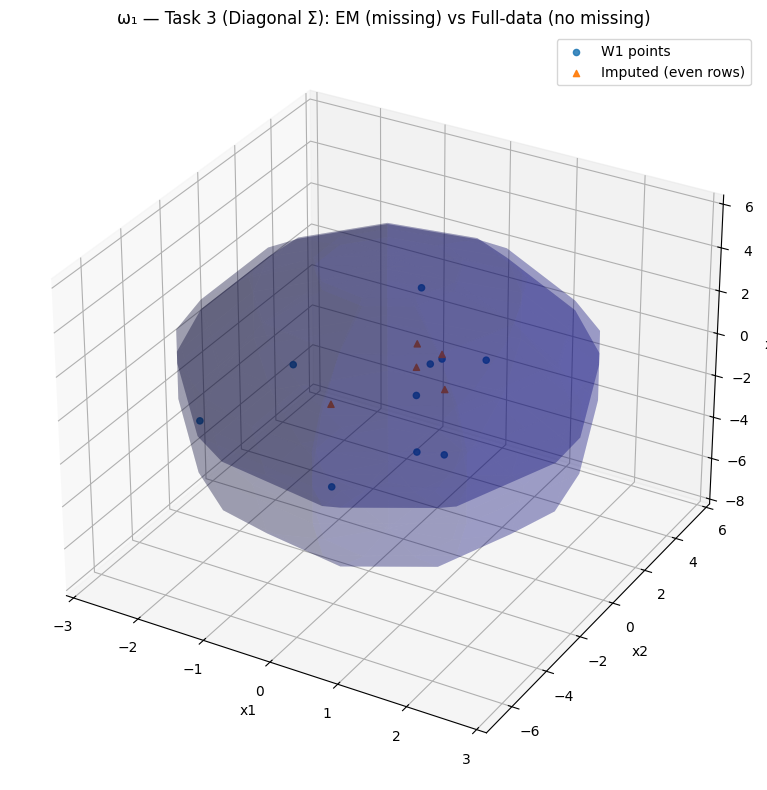


Saved figure: task3_diag_em_vs_full.png


In [5]:
# ============================================================
# Problem 3 — Task 3 (Diagonal Σ):
# Compare EM (missing x3 on even rows) vs Full-data MLE, DIAGONAL covariance
# ============================================================

import os, re, sys
import numpy as np
import matplotlib.pyplot as plt

# ---- paths (change BASE_DIR if needed) ----
BASE_DIR  = "/content/drive/MyDrive/Pattern Recognition /PA A3/"
DATA_PATH = os.path.join(BASE_DIR, "Assignment3_dataset.txt")

# import your plotting helper (visualization.py) from same folder
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)
import visualization  # uses plot_sphere()

# ---------- Load W1 (10x3) ----------
with open(DATA_PATH, "r") as f:
    raw = f.read()
w1_block = re.search(r"W1\s*(.*?)\s*W2", raw, flags=re.S|re.M).group(1).strip()
rows = [re.split(r"\s+", line.strip()) for line in w1_block.splitlines() if line.strip()]
W1 = np.array(rows, dtype=float)
assert W1.shape == (10, 3)

# ---------- Build X with missing x3 on even-numbered rows ----------
X = W1.copy()
even_idx = np.array([1,3,5,7,9])      # rows 2,4,6,8,10 (0-based)
X[even_idx, 2] = np.nan

# ============================================================
# EM for a single Gaussian with DIAGONAL covariance
#   With diag Σ, covariances are zero → E[x_m | x_o] = μ_m
# ============================================================
def em_diag_missing(X, mu0=None, var0=None, max_iter=1000, tol=1e-10):
    """
    X: NxD with np.nan for missing entries
    Returns: mu (D,), Sigma (D,D) diagonal, and X_imputed
    """
    N, D = X.shape
    mu  = np.zeros(D) if mu0 is None else mu0.astype(float)
    var = np.ones(D)  if var0 is None else var0.astype(float)  # diag entries (σ^2)

    for _ in range(max_iter):
        # E-step: expected x and x^2 for each sample/dimension
        Ex   = np.zeros((N, D))
        Ex2  = np.zeros((N, D))   # elementwise E[x_d^2]

        obs_mask = ~np.isnan(X)
        mis_mask =  np.isnan(X)

        # observed dims: Ex = x ; Ex2 = x^2
        Ex[obs_mask]  = X[obs_mask]
        Ex2[obs_mask] = X[obs_mask]**2

        # missing dims (diag Σ): E[x_d | x_o] = μ_d ; Var = σ_d^2
        if mis_mask.any():
            Ex[mis_mask]  = np.take(mu,  np.where(mis_mask)[1])
            Ex2[mis_mask] = np.take(var, np.where(mis_mask)[1]) + Ex[mis_mask]**2

        # M-step: update diagonal Gaussian params
        mu_new  = Ex.mean(axis=0)
        Ex2_bar = Ex2.mean(axis=0)           # (1/N) Σ E[x_d^2]
        var_new = Ex2_bar - mu_new**2        # diagonal variances
        var_new = np.clip(var_new, 1e-12, None)

        # convergence
        delta = np.linalg.norm(mu_new - mu) + np.linalg.norm(var_new - var)
        mu, var = mu_new, var_new
        if delta < tol:
            break

    # Impute missing with final μ (since diag Σ ⇒ conditional mean is μ_d)
    X_imp = X.copy()
    for i in range(N):
        for d in range(D):
            if np.isnan(X_imp[i,d]):
                X_imp[i,d] = mu[d]

    Sigma = np.diag(var)
    return mu, Sigma, X_imp

# ---------- Case 1: EM (missing), diagonal Σ ----------
mu_em_diag, Sigma_em_diag, X_imp = em_diag_missing(
    X, mu0=np.zeros(3), var0=np.ones(3)
)

# ---------- Case 2: Full-data MLE (no missing), diagonal Σ ----------
mu_full = W1.mean(axis=0)
Ex2_full = (W1**2).mean(axis=0)
var_full = np.clip(Ex2_full - mu_full**2, 1e-12, None)
Sigma_full_diag = np.diag(var_full)

# ---------- Print comparison (Task 3 labels) ----------
np.set_printoptions(precision=6, suppress=False)
print("=== Task 3 (Diagonal Σ) — EM with missing x3 ===")
print("mu_em_diag =", mu_em_diag)
print("diag(Sigma_em_diag) =", np.diag(Sigma_em_diag))

print("\n=== Task 3 (Diagonal Σ) — Full-data MLE (no missing) ===")
print("mu_full =", mu_full)
print("diag(Sigma_full_diag) =", np.diag(Sigma_full_diag))

print("\n=== Task 3 (Diagonal Σ) — Differences ===")
print("||mu_em - mu_full||_2 =", np.linalg.norm(mu_em_diag - mu_full))
print("||diag(Σ_em) - diag(Σ_full)||_2 =", np.linalg.norm(np.diag(Sigma_em_diag) - np.diag(Sigma_full_diag)))

# ---------- Visualization: clusters + both axis-aligned ellipsoids ----------
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(W1[:,0], W1[:,1], W1[:,2], label="W1 points", alpha=0.85)
mis_mask = np.zeros(len(W1), dtype=bool); mis_mask[even_idx] = True
ax.scatter(X_imp[mis_mask,0], X_imp[mis_mask,1], X_imp[mis_mask,2],
           marker="^", label="Imputed (even rows)", alpha=0.95)

std_em   = np.sqrt(np.diag(Sigma_em_diag))
std_full = np.sqrt(np.diag(Sigma_full_diag))

visualization.plot_sphere(w=0.25, c=mu_em_diag,  r=std_em,   ax=ax, sigma_multiplier=3)
visualization.plot_sphere(w=0.75, c=mu_full,     r=std_full, ax=ax, sigma_multiplier=3)

ax.set_title("ω₁ — Task 3 (Diagonal Σ): EM (missing) vs Full-data (no missing)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("x3")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig("task3_diag_em_vs_full.png", dpi=150)
plt.show()

print("\nSaved figure: task3_diag_em_vs_full.png")


Problem 4:

b-

Implement AIC and BIC in Python.
(Hint: I provided you the implementation in Python of AIC and BIC, you can find it in the method testGMMsklearnBICAIC in the file estimate_gmm_sklearn.py)

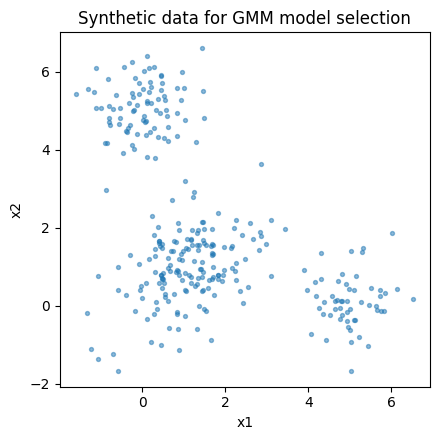

[INFO] covariance_type = 'full'
[RESULT] best k by AIC (sklearn) = 3
[RESULT] best k by BIC (sklearn) = 3
AIC manual == sklearn?  True
BIC manual == sklearn?  True


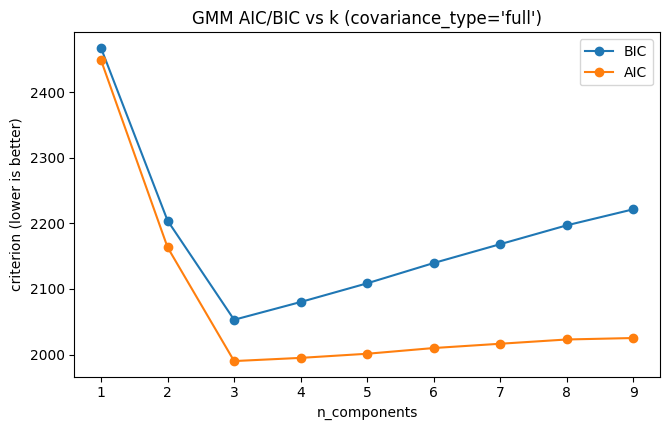

[SAVED] plot -> figure_aic_bic.png
k values: [1 2 3 4 5 6 7 8 9]
AIC values: [2448.834 2163.427 1990.004 1994.864 2001.165 2009.883 2016.42  2022.918
 2025.143]
BIC values: [2467.353 2204.169 2052.968 2080.051 2108.575 2139.515 2168.275 2196.996
 2221.443]
BEST k by AIC: 3
BEST k by BIC: 3


In [1]:
# Cell 1: imports & reproducibility
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

np.random.seed(4)  # reproducibility
# Cell 2: generate 2-D synthetic data from 3 Gaussians
def generate_data(n_data, means, covariances, weights):
    """
    n_data: total number of samples to draw
    means:  (K, D)
    covariances: (K, D, D)
    weights: length-K, sum to 1
    """
    K, D = means.shape
    X = np.zeros((n_data, D))
    for i in range(n_data):
        k = np.random.choice(K, p=weights)
        X[i] = np.random.multivariate_normal(means[k], covariances[k])
    return X

# 3 clusters in 2D (you can change N to 1000 if you like)
N = 300
means = np.array([[5, 0],
                  [1, 1],
                  [0, 5]], dtype=float)

covs = np.array([
    [[.5, 0.], [0., .5]],
    [[.92, .38], [.38, .91]],
    [[.5, 0.], [0., .5]]
], dtype=float)

weights = np.array([1/4, 1/2, 1/4], dtype=float)

X = generate_data(N, means, covs, weights)

plt.figure(figsize=(4.5,4.5))
plt.scatter(X[:,0], X[:,1], s=8, alpha=0.5)
plt.title("Synthetic data for GMM model selection")
plt.xlabel("x1"); plt.ylabel("x2")
plt.tight_layout(); plt.show()
# Cell 3: number of free parameters in a GMM
def gmm_num_params(k: int, d: int, covariance_type: str = "full") -> int:
    """
    Count parameters in a K-component, D-dimensional GMM.
      - weights: (k-1) because they sum to 1
      - means:   k*d
      - covariances depend on covariance_type
    """
    if covariance_type == "full":
        cov_params = k * (d * (d + 1) // 2)
    elif covariance_type == "diag":
        cov_params = k * d
    elif covariance_type == "tied":
        cov_params = (d * (d + 1) // 2)
    elif covariance_type == "spherical":
        cov_params = k
    else:
        raise ValueError("covariance_type must be one of {'full','diag','tied','spherical'}")

    return (k - 1) + k * d + cov_params
# Cell 4: run model selection and plot AIC/BIC
def gmm_aic_bic(
    X,
    k_min=1,
    k_max=9,
    covariance_type="full",
    max_iter=1000,
    n_init=5,
    random_state=4,
    make_plot=True,
    save_path="figure_aic_bic.png",
):
    N, d = X.shape
    ks = np.arange(k_min, k_max + 1)

    aic_sk, bic_sk = [], []
    aic_manual, bic_manual = [], []
    models = []

    for k in ks:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            max_iter=max_iter,
            n_init=n_init,
            random_state=random_state,
        ).fit(X)
        models.append(gmm)

        # sklearn versions
        aic_sk.append(gmm.aic(X))
        bic_sk.append(gmm.bic(X))

        # manual versions
        ll = gmm.score(X) * N              # total log-likelihood
        p  = gmm_num_params(k, d, covariance_type)
        aic_manual.append(2*p - 2*ll)      # AIC = 2p - 2*ll
        bic_manual.append(p*np.log(N) - 2*ll)  # BIC = p*ln(N) - 2*ll

    # pick best k
    best_k_aic = ks[np.argmin(aic_sk)]
    best_k_bic = ks[np.argmin(bic_sk)]

    # numeric agreement check
    print(f"[INFO] covariance_type = '{covariance_type}'")
    print(f"[RESULT] best k by AIC (sklearn) = {best_k_aic}")
    print(f"[RESULT] best k by BIC (sklearn) = {best_k_bic}")
    print("AIC manual == sklearn? ", np.allclose(aic_sk, aic_manual, rtol=1e-8, atol=1e-8))
    print("BIC manual == sklearn? ", np.allclose(bic_sk, bic_manual, rtol=1e-8, atol=1e-8))

    if make_plot:
        plt.figure(figsize=(6.8,4.4))
        plt.plot(ks, bic_sk, label="BIC", marker="o")
        plt.plot(ks, aic_sk, label="AIC", marker="o")
        plt.xlabel("n_components")
        plt.ylabel("criterion (lower is better)")
        plt.title(f"GMM AIC/BIC vs k (covariance_type='{covariance_type}')")
        plt.legend()
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.show()
        print(f"[SAVED] plot -> {save_path}")

    return {
        "k_values": ks,
        "models": models,
        "aic": np.array(aic_sk),
        "bic": np.array(bic_sk),
        "aic_manual": np.array(aic_manual),
        "bic_manual": np.array(bic_manual),
        "best_k_aic": int(best_k_aic),
        "best_k_bic": int(best_k_bic),
    }
# Cell 5: run model selection and draw the figure
out = gmm_aic_bic(
    X,
    k_min=1,
    k_max=9,
    covariance_type="full",
    n_init=10,
    save_path="figure_aic_bic.png"
)

print("k values:", out["k_values"])
print("AIC values:", np.round(out["aic"], 3))
print("BIC values:", np.round(out["bic"], 3))
print("BEST k by AIC:", out["best_k_aic"])
print("BEST k by BIC:", out["best_k_bic"])


c.
Draw the AIC and BIC curves for your dataset.
(Hint: you can find how to draw their curves in the method testGMMsklearnBICAIC)

[INFO] Loaded W1 from 'drive/MyDrive/Pattern Recognition /PA A3/Assignment3_dataset.txt' with shape (10, 3) and covariance_type='full'.
[RESULT] W1: best k by AIC = 9
[RESULT] W1: best k by BIC = 9
[VALUES] AIC: [ 130.226   79.833   47.619    0.755  -30.149  -66.754  -96.022 -104.966
 -111.744]
[VALUES] BIC: [132.949  85.582  56.394  12.556 -15.322 -48.902 -75.144 -81.061 -84.814]


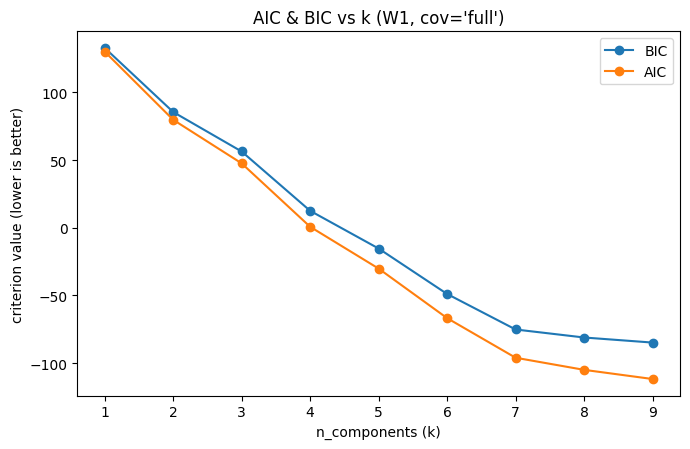

[SAVED] AIC_BIC_W1_full.png


In [3]:
# === Problem 3 → 4(c): AIC & BIC curves for W1 / W2 / W3 (single cell) ===
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# -------------------- SETTINGS (edit these two lines if you want) --------------------
DATASET_NAME   = "W1"      # choose one: "W1", "W2", or "W3"
COVARIANCE_TYP = "full"    # choose: "full" or "diag" (also supports "tied" or "spherical" if you want)
K_MIN, K_MAX   = 1, 9
N_INIT         = 50
RANDOM_STATE   = 4
# ------------------------------------------------------------------------------------

# 1) Locate the dataset file in the current folder (or immediate parent)
candidates = []
for pat in ["Assignment3_dataset.txt", "Assignment3*.txt", "**/Assignment3_dataset.txt", "**/Assignment3*.txt"]:
    candidates += glob.glob(pat, recursive=True)
if not candidates:
    raise FileNotFoundError("Couldn't find 'Assignment3_dataset.txt'. Place it in the same folder as this notebook.")
DATA_PATH = sorted(candidates, key=lambda p: len(p))[0]  # pick shortest path found

# 2) Parse the W1/W2/W3 blocks from the file
with open(DATA_PATH, "r", encoding="utf-8", errors="ignore") as f:
    raw = f.read()

def _grab_block(tag, text):
    # match tag followed by rows of 3 floats until next 'W' or EOF
    m = re.search(rf"{tag}\s*((?:[-+0-9.eE]+\s+[-+0-9.eE]+\s+[-+0-9.eE]+\s*\n)+)", text)
    if not m:
        raise ValueError(f"Couldn't parse block {tag} from {DATA_PATH}")
    rows = []
    for line in m.group(1).strip().splitlines():
        rows.append([float(x) for x in line.split()])
    return np.array(rows, dtype=float)

W1 = _grab_block("W1", raw)
W2 = _grab_block("W2", raw)
W3 = _grab_block("W3", raw)

blocks = {"W1": W1, "W2": W2, "W3": W3}
if DATASET_NAME not in blocks:
    raise ValueError("DATASET_NAME must be 'W1', 'W2', or 'W3'.")

X = blocks[DATASET_NAME]
N, D = X.shape
print(f"[INFO] Loaded {DATASET_NAME} from '{DATA_PATH}' with shape {X.shape} and covariance_type='{COVARIANCE_TYP}'.")

# 3) Compute AIC/BIC for k = K_MIN..K_MAX
ks, aics, bics = [], [], []
for k in range(K_MIN, K_MAX + 1):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COVARIANCE_TYP,
        n_init=N_INIT,
        max_iter=1000,
        random_state=RANDOM_STATE,
    ).fit(X)
    ks.append(k)
    aics.append(gmm.aic(X))
    bics.append(gmm.bic(X))

ks   = np.array(ks)
aics = np.array(aics)
bics = np.array(bics)

best_k_aic = ks[np.argmin(aics)]
best_k_bic = ks[np.argmin(bics)]

print(f"[RESULT] {DATASET_NAME}: best k by AIC = {best_k_aic}")
print(f"[RESULT] {DATASET_NAME}: best k by BIC = {best_k_bic}")
print("[VALUES] AIC:", np.round(aics, 3))
print("[VALUES] BIC:", np.round(bics, 3))

# 4) Plot & save
plt.figure(figsize=(7, 4.6))
plt.plot(ks, bics, "-o", label="BIC")
plt.plot(ks, aics, "-o", label="AIC")
plt.xlabel("n_components (k)")
plt.ylabel("criterion value (lower is better)")
plt.title(f"AIC & BIC vs k ({DATASET_NAME}, cov='{COVARIANCE_TYP}')")
plt.legend()
plt.tight_layout()
outfile = f"AIC_BIC_{DATASET_NAME}_{COVARIANCE_TYP}.png"
plt.savefig(outfile, dpi=150)
plt.show()
print(f"[SAVED] {outfile}")
